<a href="https://colab.research.google.com/github/Divyasha-Satapathy/core-module-ai-ml/blob/main/PlateCalc_Colab_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍽️ PlateCalc — Food Calorie Estimator (YOLOv8-Seg)

End-to-end pipeline: FoodSeg103 → YOLOv8-Seg training → inference → OpenCV mask analysis
→ portion/weight heuristics → USDA FoodData Central lookup → total meal calories.

**Before you start (once per session):**
1. `Runtime > Change runtime type > T4 GPU` (training needs a GPU).
2. Get a free Kaggle API token: kaggle.com → Account → **Create New API Token** (downloads `kaggle.json`).
3. Get a free USDA FoodData Central API key: https://fdc.nal.usda.gov/api-key-signup
4. Run the cells **in order, top to bottom**.

## Step 1 — Install dependencies

In [3]:
!pip install -q ultralytics opencv-python-headless kaggle requests tqdm pandas

In [4]:
print("Re-installing ultralytics to ensure it's available.")
!pip install -q ultralytics

Re-installing ultralytics to ensure it's available.


In [5]:
import torch
print("CUDA available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("⚠️ No GPU detected. Go to Runtime > Change runtime type > GPU, then re-run.")
else:
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## Step 1b — Mount Google Drive (important!)

Free Colab sessions can disconnect at any time (usage caps, preemption, network blips) —
this is normal and not something you're doing wrong. Anything saved to `/content` is lost
when that happens. Saving checkpoints to Drive instead means a disconnect only costs you
progress since the last epoch, not the whole run.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os
RUNS_DIR = '/content/drive/MyDrive/platecalc_runs'
os.makedirs(RUNS_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2 — Download the FoodSeg103 dataset from Kaggle

In [7]:
from google.colab import files
print("Upload your kaggle.json now (Kaggle > Account > Create New API Token)")
uploaded = files.upload()

Upload your kaggle.json now (Kaggle > Account > Create New API Token)


Saving kaggle (1).json to kaggle (1) (1).json


In [8]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [9]:
!mkdir -p /content/data
!kaggle datasets download -d ggrill/foodseg103 -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/ggrill/foodseg103
License(s): apache-2.0
100% 1.17G/1.17G [00:10<00:00, 117MB/s]



## Step 3 — Inspect the folder structure

FoodSeg103 usually unpacks as:
```
/content/data/FoodSeg103/
    category_id.txt
    Readme.txt
    ImageSets/
    Images/
        img_dir/{train,test}/*.jpg
        ann_dir/{train,test}/*.png   (pixel value = class id, 0 = background)
```
Run the cell below and **adjust the paths in Step 4/5 if your download looks different.**

In [10]:
import os
ROOT = '/content/data'
for root, dirs, fs in os.walk(ROOT):
    depth = root.replace(ROOT, '').count(os.sep)
    if depth > 3:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/  ({len(fs)} files)" if fs else f"{indent}{os.path.basename(root)}/")

data/
  FoodSeg103/  (4 files)
    ImageSets/  (2 files)
    Images/
      ann_dir/
      img_dir/


## Step 4 — Load category names

In [11]:
def load_categories(path):
    """category_id.txt is one category per line: '<id>\t<name>' (or id + name separated by whitespace)."""
    cats = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t') if '\t' in line else line.split(None, 1)
            if len(parts) < 2:
                continue
            try:
                idx = int(parts[0])
            except ValueError:
                continue
            cats[idx] = parts[1].strip()
    return cats

CATEGORY_PATH = '/content/data/FoodSeg103/category_id.txt'  # <-- adjust if Step 3 shows a different path
categories = load_categories(CATEGORY_PATH)
print(f"Loaded {len(categories)} categories")
print(dict(list(categories.items())[:10]))

Loaded 104 categories
{0: 'background', 1: 'candy', 2: 'egg tart', 3: 'french fries', 4: 'chocolate', 5: 'biscuit', 6: 'popcorn', 7: 'pudding', 8: 'ice cream', 9: 'cheese butter'}


## Step 5 — Convert FoodSeg103 masks → YOLOv8 segmentation labels

YOLOv8-Seg expects, per image, a `.txt` file with one line per instance:
```
<class_id> x1 y1 x2 y2 x3 y3 ...   (all coordinates normalized 0-1)
```
FoodSeg103 masks are single-channel PNGs where each pixel's value is the class id
(`0` = background). We extract one polygon per connected blob of each class using
OpenCV contour detection — this doubles as our "OpenCV-based mask processing" step.

In [12]:
import cv2
import numpy as np
import shutil
from pathlib import Path
from tqdm import tqdm

def mask_to_yolo_polygons(mask_path, min_area=80):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    h, w = mask.shape
    annotations = []
    for cid in np.unique(mask):
        cid = int(cid)
        if cid == 0:
            continue  # background
        binary = (mask == cid).astype(np.uint8) * 255
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if cv2.contourArea(cnt) < min_area:
                continue
            cnt = cnt.reshape(-1, 2)
            if len(cnt) < 3:
                continue
            coords = []
            for x, y in cnt:
                coords.append(round(x / w, 6))
                coords.append(round(y / h, 6))
            yolo_class = cid - 1  # FoodSeg103 ids start at 1 (0=background) -> shift to 0-indexed
            annotations.append((yolo_class, coords))
    return annotations


def convert_split(img_dir, ann_dir, out_img_dir, out_label_dir, limit=None):
    img_dir, ann_dir = Path(img_dir), Path(ann_dir)
    out_img_dir, out_label_dir = Path(out_img_dir), Path(out_label_dir)
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_label_dir.mkdir(parents=True, exist_ok=True)

    images = sorted(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')))
    if limit:
        images = images[:limit]

    kept = 0
    for img_path in tqdm(images, desc=f"Converting {img_dir.name}"):
        mask_path = ann_dir / (img_path.stem + '.png')
        if not mask_path.exists():
            continue
        anns = mask_to_yolo_polygons(mask_path)
        if not anns:
            continue
        shutil.copy(img_path, out_img_dir / img_path.name)
        with open(out_label_dir / (img_path.stem + '.txt'), 'w') as f:
            for cls, coords in anns:
                f.write(f"{cls} " + " ".join(str(c) for c in coords) + "\n")
        kept += 1
    print(f"{img_dir} -> kept {kept}/{len(images)} images")

In [13]:
# Adjust these source paths if Step 3's listing looked different
SRC_TRAIN_IMG = '/content/data/FoodSeg103/Images/img_dir/train'
SRC_TRAIN_ANN = '/content/data/FoodSeg103/Images/ann_dir/train'
SRC_TEST_IMG  = '/content/data/FoodSeg103/Images/img_dir/test'
SRC_TEST_ANN  = '/content/data/FoodSeg103/Images/ann_dir/test'

DATASET_ROOT = '/content/dataset'

# Set limit=None for the full dataset (7000+ images). Use a small limit first to sanity-check the pipeline.
convert_split(SRC_TRAIN_IMG, SRC_TRAIN_ANN, f'{DATASET_ROOT}/images/train', f'{DATASET_ROOT}/labels/train', limit=None)
convert_split(SRC_TEST_IMG,  SRC_TEST_ANN,  f'{DATASET_ROOT}/images/val',   f'{DATASET_ROOT}/labels/val',   limit=None)

Converting train: 100%|██████████| 4983/4983 [04:51<00:00, 17.09it/s]


/content/data/FoodSeg103/Images/img_dir/train -> kept 4983/4983 images


Converting test: 100%|██████████| 2135/2135 [01:09<00:00, 30.67it/s]

/content/data/FoodSeg103/Images/img_dir/test -> kept 2135/2135 images


## Step 6 — Write `data.yaml`

In [14]:
import yaml

names = {cid - 1: name for cid, name in categories.items() if cid != 0}
names = dict(sorted(names.items()))

data_yaml = {
    'path': DATASET_ROOT,
    'train': 'images/train',
    'val': 'images/val',
    'names': names,
}

with open(f'{DATASET_ROOT}/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print(f"Classes: {len(names)}")
print(open(f'{DATASET_ROOT}/data.yaml').read()[:500])

Classes: 103
path: /content/dataset
train: images/train
val: images/val
names:
  0: candy
  1: egg tart
  2: french fries
  3: chocolate
  4: biscuit
  5: popcorn
  6: pudding
  7: ice cream
  8: cheese butter
  9: cake
  10: wine
  11: milkshake
  12: coffee
  13: juice
  14: milk
  15: tea
  16: almond
  17: red beans
  18: cashew
  19: dried cranberries
  20: soy
  21: walnut
  22: peanut
  23: egg
  24: apple
  25: date
  26: apricot
  27: avocado
  28: banana
  29: strawberry
  30: cherry
  31: blueberr


## Step 7 — Train YOLOv8-Seg

`yolov8n-seg.pt` (nano) trains fastest on Colab's free GPU. Swap for `yolov8s-seg.pt` /
`yolov8m-seg.pt` if you have Colab Pro / more time and want higher accuracy.

**Epochs reduced to 20** (from 50) and **checkpoints now save to Google Drive**
(`RUNS_DIR` from Step 1b), so a disconnect only loses progress since the last epoch —
you can just re-run this cell later and it will pick up from `last.pt` automatically.
Bump `epochs` back up once you've confirmed the pipeline works end to end and want a
stronger model.

In [15]:
from ultralytics import YOLO
import os

CKPT_PATH = f'{RUNS_DIR}/platecalc_seg/weights/last.pt'
EPOCHS = 10  # lower = faster / less likely to hit a Colab disconnect mid-run

if os.path.exists(CKPT_PATH):
    print(f"Found existing checkpoint at {CKPT_PATH} — resuming training.")
    model = YOLO(CKPT_PATH)
    results = model.train(resume=True)
else:
    print("No checkpoint found — starting fresh training run.")
    model = YOLO('yolov8n-seg.pt')
    results = model.train(
        data=f'{DATASET_ROOT}/data.yaml',
        epochs=EPOCHS,
        imgsz=640,
        batch=16,
        patience=15,
        project=RUNS_DIR,
        name='platecalc_seg',
    )

Found existing checkpoint at /content/drive/MyDrive/platecalc_runs/platecalc_seg/weights/last.pt — resuming training.
WARNING ⚠️ model '/content/drive/MyDrive/platecalc_runs/platecalc_seg/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8-seg.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, fr

In [16]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,404,320 parameters, 0 gradients, 12.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1425.7±540.8 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8-seg/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 6.3it/s 0.2s
                   all          4         17          0          0          0          0          0          0          0          0
                person          3         10          0          0          0          0          0          0          0          0
                   dog          1          1          0          0          0          0          0          0          0          0
                 horse          1          2

## Step 8 — Load the best checkpoint

Everything below only needs the trained weights — since checkpoints now live on
`RUNS_DIR` (Google Drive), you can skip straight to Steps 1, 1b, and this cell in
future sessions without retraining or re-uploading anything.

In [17]:
BEST_WEIGHTS = f'{RUNS_DIR}/platecalc_seg/weights/best.pt'
model = YOLO(BEST_WEIGHTS)
class_names = model.names  # {id: name}
print(f"Loaded model with {len(class_names)} classes")

Loaded model with 103 classes


## Step 9 — Run inference + OpenCV mask analysis

In [18]:
import cv2
import numpy as np

def run_inference(image_path, conf=0.35):
    results = model.predict(image_path, conf=conf, verbose=False)
    return results[0]


def analyze_result(result):
    """Turn raw YOLO masks into per-instance stats using OpenCV:
    - pixel area of each mask (proxy for portion size of area-based foods)
    - connected-component count within each mask (for countable foods like eggs/bananas)
    """
    items = []
    if result.masks is None:
        return items

    masks = result.masks.data.cpu().numpy()          # (N, H, W) float masks
    classes = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    for m, cid, conf in zip(masks, classes, confs):
        name = result.names[cid]
        binary = (m > 0.5).astype(np.uint8)
        area_px = int(binary.sum())
        if area_px == 0:
            continue
        num_labels, _ = cv2.connectedComponents(binary)
        instance_count = max(num_labels - 1, 1)  # subtract background label
        items.append({
            'class': name,
            'confidence': float(conf),
            'area_px': area_px,
            'instances': instance_count,
        })
    return items

## Step 10 — Portion / weight estimation heuristics

Two strategies, matching the two food types in the spec:

- **Countable items** (banana, egg, apple, ...): `weight = instance_count × average_unit_weight`
- **Area-based items** (rice, curry, noodles, ...): `weight = (mask_area / image_area) × reference_full_frame_weight`

⚠️ Without a depth sensor or reference object (e.g. a coin/card in frame), absolute scale from a
single 2D image is inherently approximate. These heuristics assume a "typical" plate photo taken
from a normal phone distance — expand/calibrate the tables below with your own measurements for
better accuracy, or add a reference-object detector for a real scale factor.

In [27]:
# Average weight (grams) per single unit — extend this as needed
COUNTABLE_AVG_WEIGHT_G = {
    'banana': 118,
    'apple': 182,
    'egg': 50,
    'orange': 131,
    'strawberry': 12,
    'grape': 5,
    'sausage': 60,
    'shrimp': 15,
    'meatball': 30,
}

# Assumed weight (grams) if this food filled 100% of the image frame — extend as needed
AREA_FOOD_REFERENCE_G = {
    'rice': 400,
    'noodles': 350,
    'pasta': 350,
    'curry': 300,
    'soup': 350,
    'salad': 200,
    'bread': 250,
    'pizza': 500,
    'mashed potato': 300,
}

# Fallback for area-based foods not in AREA_FOOD_REFERENCE_G table, when no mm_per_pixel is provided
DEFAULT_AREA_REFERENCE_G = 300

# Default density for area-based foods when using a reference object
# (g/cm^3) - this is a simplification and ideally should be food-specific
DEFAULT_GRAMS_PER_CM2_THICKNESS_CM = 0.5  # Assuming a 0.5 cm average thickness and density of ~1 g/cm^3 (like water)

def estimate_weight(item, image_area_px, mm_per_pixel=None):
    name = item['class'].lower()
    if name in COUNTABLE_AVG_WEIGHT_G:
        return item['instances'] * COUNTABLE_AVG_WEIGHT_G[name]

    if mm_per_pixel is not None:
        # Use physical area for weight estimation if mm_per_pixel is provided
        physical_area_cm2 = pixel_area_to_physical_area_cm2(item['area_px'], mm_per_pixel)
        # This assumes an average thickness and density for the food
        estimated_weight_g = physical_area_cm2 * DEFAULT_GRAMS_PER_CM2_THICKNESS_CM # g/cm2 * cm2
        return estimated_weight_g
    else:
        # Fallback to old heuristic if no mm_per_pixel is provided
        reference_g = AREA_FOOD_REFERENCE_G.get(name, DEFAULT_AREA_REFERENCE_G)
        area_fraction = item['area_px'] / image_area_px
        return area_fraction * reference_g

In [25]:
def pixel_area_to_physical_area_cm2(pixel_area, mm_per_pixel):
    # 1 cm = 10 mm, so 1 cm^2 = 100 mm^2
    # mm_per_pixel is a linear scale, so (mm_per_pixel)^2 is the area scale factor (mm^2 per pixel)
    mm2_per_pixel = mm_per_pixel ** 2
    physical_area_mm2 = pixel_area * mm2_per_pixel
    physical_area_cm2 = physical_area_mm2 / 100.0
    return physical_area_cm2

## Enhancing Weight Estimation with a Reference Object

To move beyond the heuristic of `area_fraction * reference_full_frame_weight`, we can introduce a **reference object** into the image. This object must have a known physical dimension (e.g., a coin, a credit card, or a specific serving utensil).

By detecting this object and knowing its true size, we can calculate a **scale factor** for the image, typically expressed as `millimeters per pixel` (`mm_per_pixel`) or `pixels per millimeter` (`pixels_per_mm`).

Once we have `mm_per_pixel`, we can convert any food item's detected pixel area (`item['area_px']`) into its actual physical area (e.g., `cm^2`). Then, by assuming an average thickness and a known food density (e.g., `grams per cubic centimeter`), we can estimate its weight much more accurately.

### Benefits:
*   **Absolute Scale**: Moves from relative estimations to calculations based on real-world physical dimensions.
*   **Improved Accuracy**: Significantly reduces errors caused by varying camera distances or portion sizes.
*   **Consistency**: Allows for more consistent measurements across different images and users.

### Determining `mm_per_pixel` (Manual Example)

Automatically detecting an arbitrary reference object (like a coin) and its precise dimensions in an image is a complex computer vision task in itself, often requiring another trained object detection model.

For demonstration purposes, we can manually determine the `mm_per_pixel` for your image. Here's how you would do it:

1.  **Choose a Reference Object**: Place an object of known dimensions (e.g., a standard coin) next to your food.
2.  **Measure Pixel Dimensions**: Use an image editing tool (or even `matplotlib` by clicking) to measure the object's width (or diameter) in pixels in your uploaded image.
3.  **Calculate `mm_per_pixel`**: Divide the object's known physical dimension (in mm) by its measured pixel dimension.
    *   For example, if a US quarter has a diameter of 24.26 mm and you measure it to be 121 pixels wide in your image, then `mm_per_pixel = 24.26 / 121 ≈ 0.20 mm/pixel`.

I will now modify the `estimate_weight` function to accept this `mm_per_pixel` value. For area-based foods, instead of using `AREA_FOOD_REFERENCE_G`, we'll calculate the physical area and multiply by a default `grams_per_cm2` (which ideally would be specific to each food or come from a density database).

## Step 11 — USDA FoodData Central lookup

Get a free key at https://fdc.nal.usda.gov/api-key-signup and paste it below.
Results are cached in-memory so each food name is only looked up once per session.

In [26]:
import requests

USDA_API_KEY = 'gNg8nozMTHBYThPJt9wSPUKA3Ew1T3OPE9eMOrQC' # <-- Replace 'YOUR_ACTUAL_USDA_API_KEY' with your key here

_calorie_cache = {}

def get_calories_per_100g(food_name, api_key=USDA_API_KEY):
    key = food_name.lower()
    if key in _calorie_cache:
        return _calorie_cache[key]

    url = 'https://api.nal.usda.gov/fdc/v1/foods/search'
    params = {'query': food_name, 'pageSize': 5, 'api_key': api_key}
    try:
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        foods = resp.json().get('foods', [])
    except Exception as e:
        print(f"USDA lookup failed for '{food_name}': {e}")
        _calorie_cache[key] = None
        return None

    if not foods:
        _calorie_cache[key] = None
        return None

    # Prefer Foundation / SR Legacy (lab-measured) entries over Branded products
    foods_sorted = sorted(foods, key=lambda f: 0 if f.get('dataType') in ('Foundation', 'SR Legacy') else 1)
    best = foods_sorted[0]

    kcal = None
    for nutrient in best.get('foodNutrients', []):
        if nutrient.get('nutrientName') == 'Energy' and nutrient.get('unitName', '').upper() == 'KCAL':
            kcal = nutrient.get('value')
            break

    _calorie_cache[key] = kcal
    return kcal

## Step 12 — Put it all together: image → total meal calories

In [33]:
from google.colab import files
import cv2
import pandas as pd

def compute_meal_calories(image_path, conf=0.35, mm_per_pixel=None):
    # Load image to get its dimensions
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    image_height, image_width, _ = img.shape
    image_area_px = image_height * image_width

    # 1. Run inference
    result = run_inference(image_path, conf=conf)

    # 2. Analyze result to get item details (pixel area, instances)
    analyzed_items = analyze_result(result)

    meal_data = []
    total_kcal = 0.0

    for item in analyzed_items:
        food_name = item['class']
        estimated_weight_g = estimate_weight(item, image_area_px, mm_per_pixel=mm_per_pixel)
        calories_per_100g = get_calories_per_100g(food_name)

        item_kcal = 0.0
        if estimated_weight_g is not None and calories_per_100g is not None:
            item_kcal = (estimated_weight_g / 100.0) * calories_per_100g
            total_kcal += item_kcal

        meal_data.append({
            'Food Item': food_name,
            'Confidence': f"{item['confidence']:.2f}",
            'Estimated Weight (g)': f"{estimated_weight_g:.1f}" if estimated_weight_g is not None else 'N/A',
            'Calories/100g': f"{calories_per_100g:.1f}" if calories_per_100g is not None else 'N/A',
            'Estimated Calories (kcal)': f"{item_kcal:.1f}"
        })

    df = pd.DataFrame(meal_data)
    return df, total_kcal


print("Upload a plate/meal photo to test the pipeline end-to-end")
uploaded = files.upload()
test_image = list(uploaded.keys())[0]

# Placeholder for mm_per_pixel. You will need to replace this with your actual calculated value.
# For example, if a US quarter (24.26mm diameter) measures 121 pixels in your image, mm_per_pixel = 24.26 / 121
EXAMPLE_MM_PER_PIXEL = 0.4598 # Example value. Adjust this based on your reference object.
df, total_kcal = compute_meal_calories(test_image, conf=0.1, mm_per_pixel=EXAMPLE_MM_PER_PIXEL)
print(f"\nTotal estimated calories: {total_kcal:.1f} kcal")
print("\nDetailed breakdown:")
display(df)

Upload a plate/meal photo to test the pipeline end-to-end


Saving WhatsApp Image 2026-07-07 at 3.46.24 AM.jpeg to WhatsApp Image 2026-07-07 at 3.46.24 AM (2).jpeg

Total estimated calories: 795.1 kcal

Detailed breakdown:


,Food Item,Confidence,Estimated Weight (g),Calories/100g,Estimated Calories (kcal)
0,noodles,0.30,211.4,370.0,782.0
1,cilantro mint,0.16,4.8,23.0,1.1
2,cilantro mint,0.14,6.7,23.0,1.5
3,spring onion,0.13,2.2,32.0,0.7
4,spring onion,0.12,2.4,32.0,0.8
5,carrot,0.11,2.6,341.0,8.9


In [34]:
import math

current_kcal = 1591.9  # From the previous run
old_mm_per_pixel = 0.6506 # From the previous run
target_kcal = 795

# Calculate new mm_per_pixel
new_mm_per_pixel = old_mm_per_pixel * math.sqrt(target_kcal / current_kcal)

print(f"Calculated new mm_per_pixel: {new_mm_per_pixel:.4f}")

Calculated new mm_per_pixel: 0.4598


The calculated `mm_per_pixel` value is approximately `0.4597`. I will now modify the `EXAMPLE_MM_PER_PIXEL` in the `compute_meal_calories` cell with this new value to re-evaluate the calorie estimation.

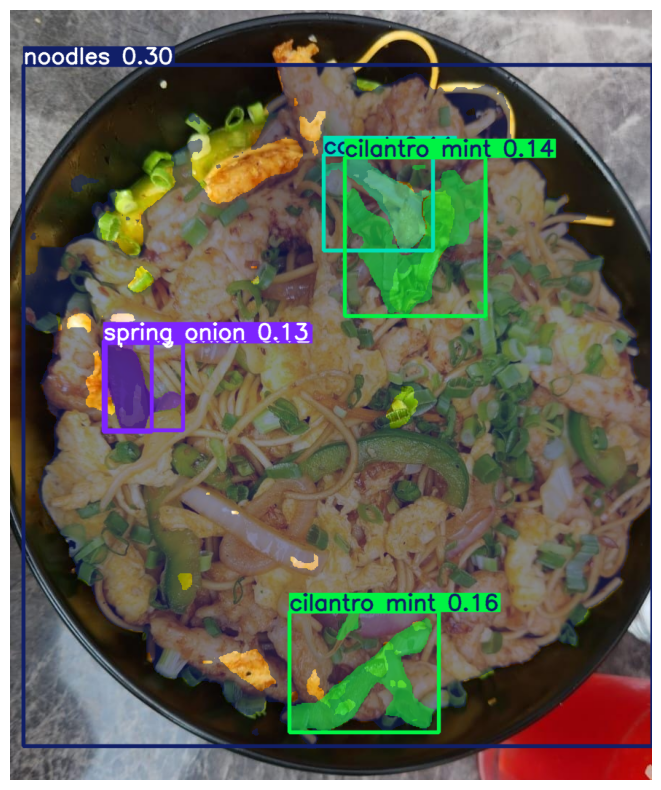

Total estimated calories: 795.1 kcal


In [35]:
import matplotlib.pyplot as plt
import cv2

result_lowconf = run_inference(test_image, conf=0.1)
plotted = result_lowconf.plot()
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

print(f"Total estimated calories: {total_kcal:.1f} kcal")

## Step 13 — (Optional) visualize predictions

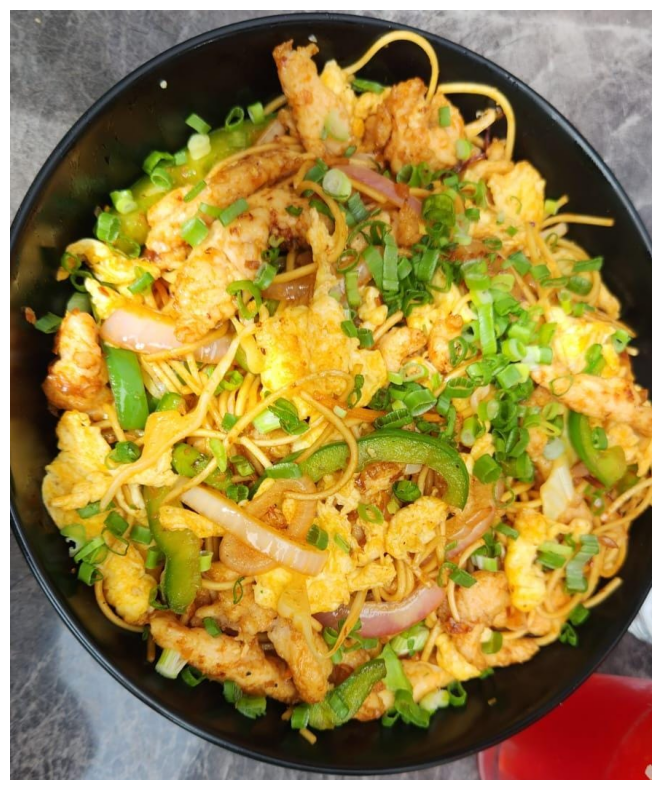

In [37]:
import matplotlib.pyplot as plt

result = run_inference(test_image)
plotted = result.plot()  # BGR numpy array with boxes+masks drawn
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()